In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.utils import resample

import xgboost as xgb

In [2]:
!pip install xgboost

**LOAD DATA**

In [3]:
df = pd.read_csv('student_performance.csv')
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


**DATA UNDERSTANDING**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525930 entries, 0 to 525929
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               525930 non-null  int64  
 1   weekly_self_study_hours  525930 non-null  float64
 2   attendance_percentage    525930 non-null  float64
 3   class_participation      525930 non-null  float64
 4   total_score              525930 non-null  float64
 5   grade                    525929 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 24.1+ MB


In [5]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,525930.000000,525930.000000,525930.000000,525930.000000,525930.000000
mean,262965.500000,15.030606,84.719530,5.985277,84.278535
std,151823.057874,6.901032,9.427366,1.956655,15.437528
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,131483.250000,10.300000,78.300000,4.700000,73.900000
50%,262965.500000,15.000000,85.000000,6.000000,87.500000
75%,394447.750000,19.700000,91.800000,7.300000,100.000000
max,525930.000000,40.000000,100.000000,10.000000,100.000000


In [6]:
df.shape

(525930, 6)

In [7]:
df = pd.read_csv('student_performance.csv')
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


**FILTER KELAS**

In [8]:
df = df[df['grade'].isin(['A','B','C'])]

df['grade'].value_counts()

,count
grade,
A,288354
B,136037
C,74499


In [9]:
# Pisahkan tiap kelas
df_A = df[df['grade'] == 'A']
df_B = df[df['grade'] == 'B']
df_C = df[df['grade'] == 'C']

# Jumlah kelas C
n_samples = len(df_C)

# Downsampling A dan B
df_A_balanced = resample(
    df_A,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

df_B_balanced = resample(
    df_B,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

# Gabungkan kembali
df_balanced = pd.concat([df_A_balanced, df_B_balanced, df_C])

# Acak dataset
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Cek hasil
df_balanced['grade'].value_counts()

,count
grade,
A,74499
C,74499
B,74499


In [10]:
df = df_balanced.copy()

In [11]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


**OUTLIER**

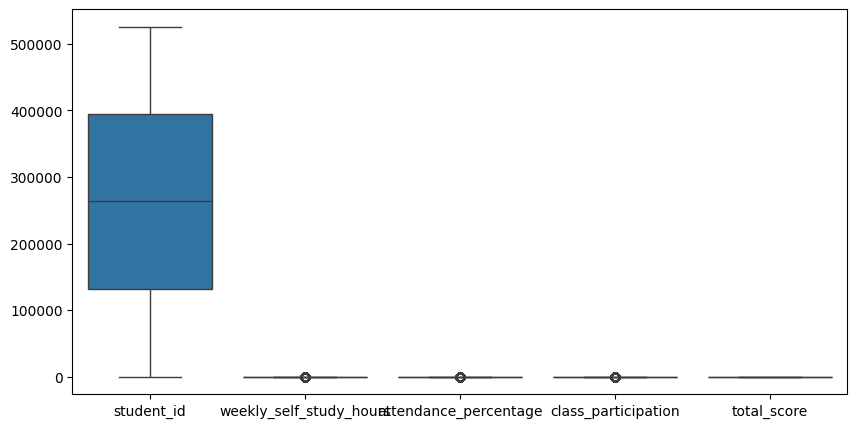

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

**TARGET**

In [51]:
X = df.drop(['grade','student_id'], axis=1)
y = df['grade']

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223497 entries, 94137 to 424847
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   weekly_self_study_hours  223497 non-null  float64
 1   attendance_percentage    223497 non-null  float64
 2   class_participation      223497 non-null  float64
 3   total_score              223497 non-null  float64
dtypes: float64(4)
memory usage: 8.5 MB


**ENCODING**

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['grade'] = le.fit_transform(df['grade'])
y = le.fit_transform(df['grade'])

In [16]:
np.unique(df['grade'])

array([0, 1, 2])

**EDA**

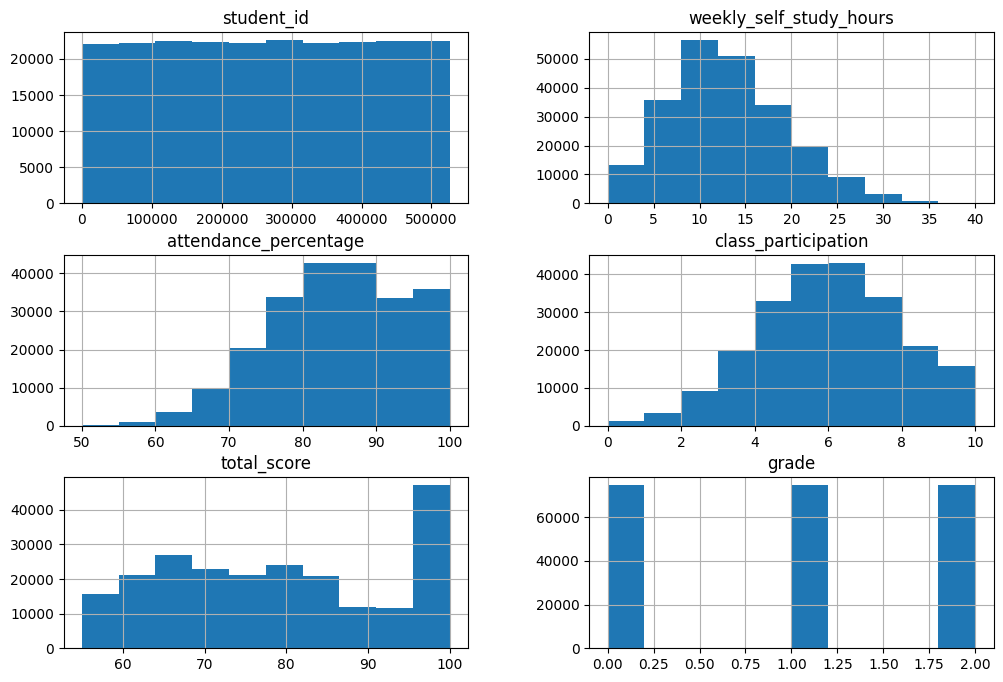

In [17]:
df.hist(figsize=(12,8))
plt.show()

**KORELASI**

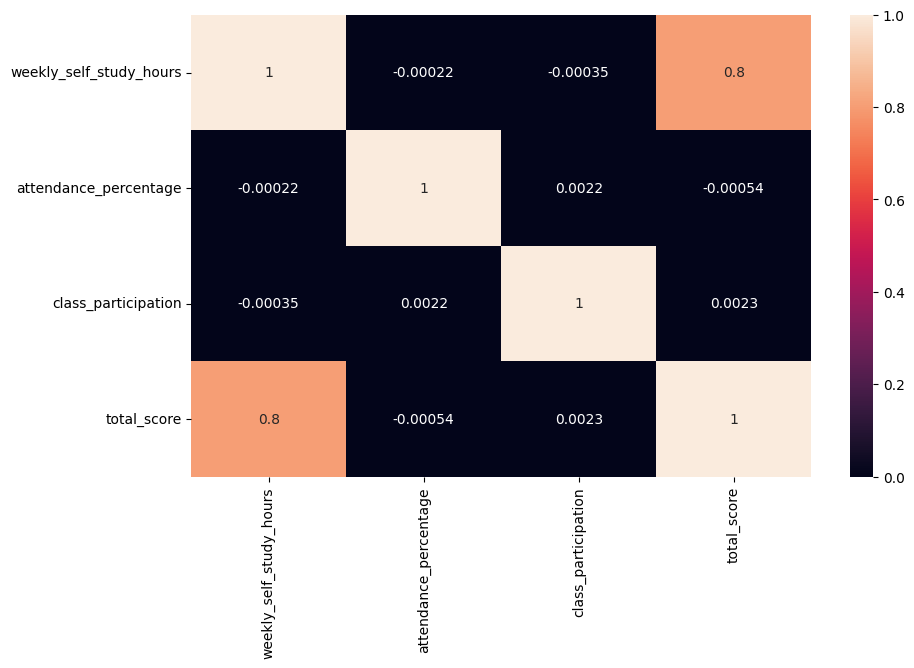

In [18]:
plt.figure(figsize=(10,6))
# Drop non-numeric columns 'student_id', 'grade', and 'dropout' before calculating correlation
sns.heatmap(df.drop(columns=['student_id', 'grade']).corr(), annot=True)
plt.show()

**SPLIT FEATURE**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**MODEL**

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [22]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**HYPER TUNING**

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators': [100,200],
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

rf_tuning = RandomizedSearchCV(
    rf,
    param_rf,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

rf_tuning.fit(X_train, y_train)

best_rf = rf_tuning.best_estimator_

print("Best Random Forest Parameter")
print(rf_tuning.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Parameter
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3}


In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingClassifier(random_state=42)

param_gb = {
    'n_estimators':[100,200],
    'learning_rate':[0.05,0.1],
    'max_depth':[3,4]
}

gb_tuning = RandomizedSearchCV(
    gb,
    param_gb,
    n_iter=5,
    cv=2,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

gb_tuning.fit(X_train, y_train)

best_gb = gb_tuning.best_estimator_

print("Best Gradient Boosting Parameter")
print(gb_tuning.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Gradient Boosting Parameter
{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


In [25]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

param_xgb = {
    'n_estimators':[100,200],
    'max_depth':[3,4,5,6],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,0.9,1],
    'colsample_bytree':[0.8,0.9,1]
}

xgb_tuning = RandomizedSearchCV(
    xgb_model,
    param_xgb,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

xgb_tuning.fit(X_train, y_train)

best_xgb = xgb_tuning.best_estimator_

print("Best XGBoost Parameter")
print(xgb_tuning.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameter
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1}


**PREDICTION**

**EVALUASI**

In [26]:
from sklearn.metrics import accuracy_score

pred_rf = best_rf.predict(X_test)
pred_gb = best_gb.predict(X_test)
pred_xgb = best_xgb.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
acc_gb = accuracy_score(y_test, pred_gb)
acc_xgb = accuracy_score(y_test, pred_xgb)

print("Random Forest Accuracy :", acc_rf)
print("Gradient Boosting Accuracy :", acc_gb)
print("XGBoost Accuracy :", acc_xgb)

Random Forest Accuracy : 0.9987472035794184
Gradient Boosting Accuracy : 0.998724832214765
XGBoost Accuracy : 0.9968456375838927


In [27]:
comparison = pd.DataFrame({
    "Model":["Random Forest","Gradient Boosting","XGBoost"],
    "Accuracy":[acc_rf,acc_gb,acc_xgb]
})

comparison

,Model,Accuracy
0,Random Forest,0.998747
1,Gradient Boosting,0.998725
2,XGBoost,0.996846


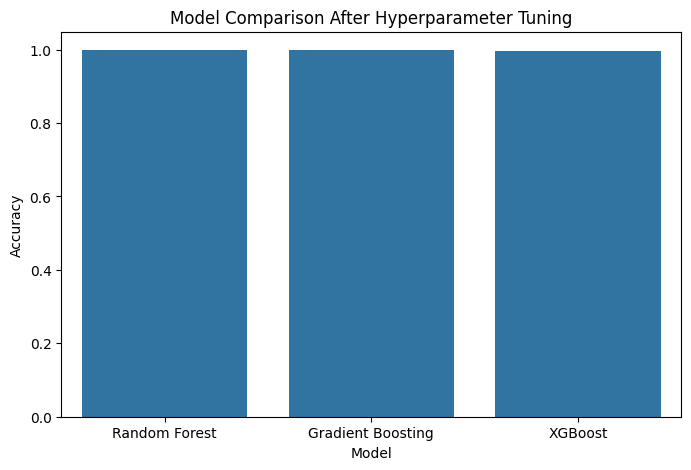

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Comparison After Hyperparameter Tuning")

plt.show()

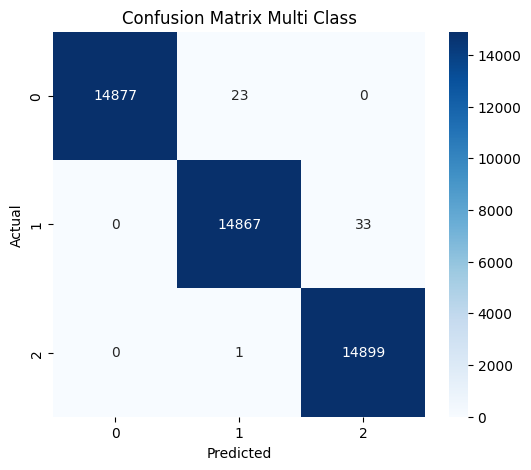

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix Multi Class")

plt.show()

**TES OVER FITTING**

In [30]:
def check_overfitting(model, X_train, y_train, X_test, y_test, name):

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"{name}")
    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)
    print("-----------------------------")

In [31]:
check_overfitting(best_gb, X_train, y_train, X_test, y_test, "Gradient Boosting")

check_overfitting(best_rf, X_train, y_train, X_test, y_test, "Random Forest")

check_overfitting(best_xgb, X_train, y_train, X_test, y_test, "XGBoost")

Gradient Boosting
Training Accuracy : 0.998674474403933
Testing Accuracy  : 0.998724832214765
-----------------------------
Random Forest
Training Accuracy : 0.9986521026639149
Testing Accuracy  : 0.9987472035794184
-----------------------------
XGBoost
Training Accuracy : 0.9969350716175327
Testing Accuracy  : 0.9968456375838927
-----------------------------


**FEATURE IMPORTANCE**

In [32]:
importance = best_gb.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
3,total_score,0.999911
1,attendance_percentage,0.000046
0,weekly_self_study_hours,0.000021
2,class_participation,0.000021


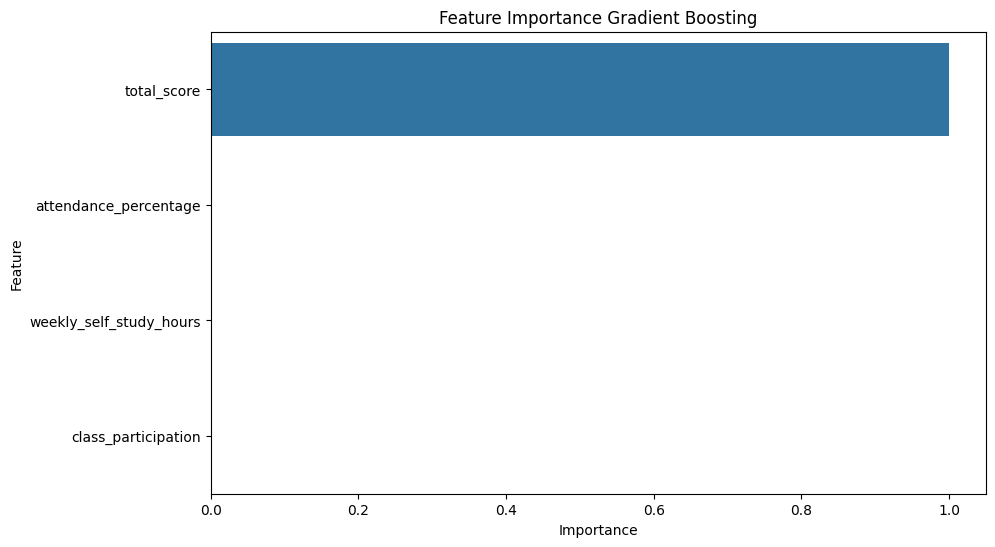

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance Gradient Boosting')
plt.show()

**INFERENCE**

In [34]:
best_model = max(
    [(best_rf, acc_rf),
     (best_gb, acc_gb),
     (best_xgb, acc_xgb)],
    key=lambda x: x[1]
)[0]

In [35]:
import joblib

joblib.dump(best_model, 'model_dropout.pkl')

['model_dropout.pkl']

In [36]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [37]:
import joblib

model = joblib.load('model_dropout.pkl')
label_encoder = joblib.load('label_encoder.pkl')

In [38]:
import pandas as pd

# Data mahasiswa baru
data_baru = pd.DataFrame({
    'attendance':[80],
    'assignment':[75],
    'midterm':[70],
    'final':[65],
    'study_hours':[3],
    'class_participation':[4]
})

In [39]:
# Buat fitur seperti saat training
data_baru['attendance_percentage'] = data_baru['attendance']

data_baru['total_score'] = (
    data_baru['assignment'] +
    data_baru['midterm'] +
    data_baru['final']
) / 3

data_baru['weekly_self_study_hours'] = data_baru['study_hours']

In [40]:
data_baru = data_baru[[
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation',
    'total_score'
]]

In [41]:
prediksi = model.predict(data_baru)

hasil = label_encoder.inverse_transform(prediksi)

print("Prediksi Risiko Dropout :", hasil[0])

Prediksi Risiko Dropout : 2


In [42]:
def predict_dropout(data):

    pred = model.predict(data)
    label = label_encoder.inverse_transform(pred)

    prob = model.predict_proba(data)

    return label[0], prob

In [43]:
label, prob = predict_dropout(data_baru)

print("Prediksi :", label)
print("Probabilitas :", prob)

Prediksi : 2
Probabilitas : [[0.00921405 0.17511827 0.81566768]]


**KUMPULAN VISUALISASI**

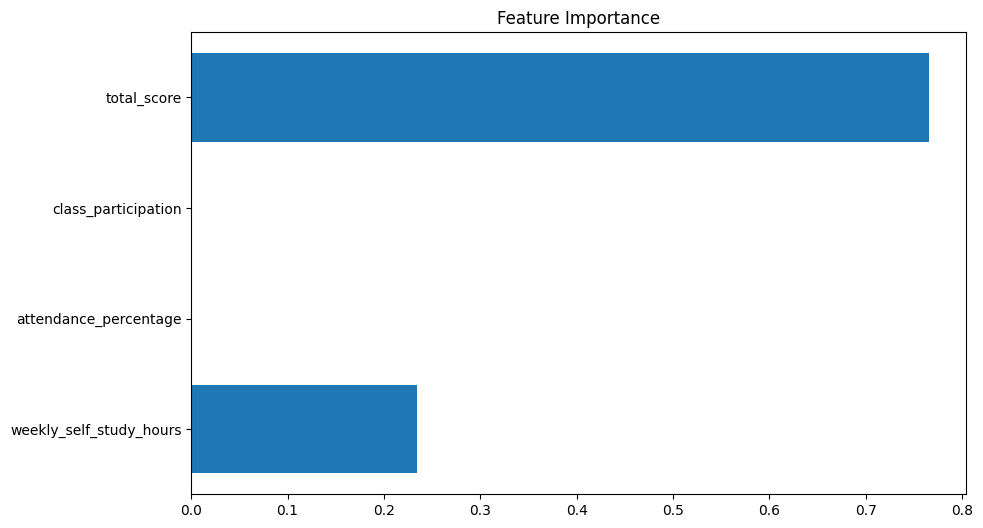

In [44]:
import matplotlib.pyplot as plt

feature_importance = best_model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, feature_importance)

plt.title("Feature Importance")
plt.show()

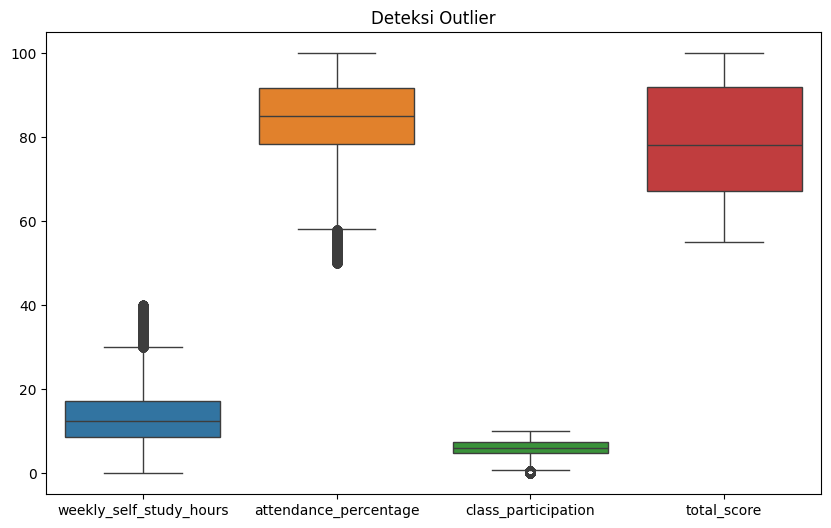

In [45]:
plt.figure(figsize=(10,6))
sns.boxplot(data=X)
plt.title("Deteksi Outlier")
plt.show()

<Figure size 1000x800 with 0 Axes>

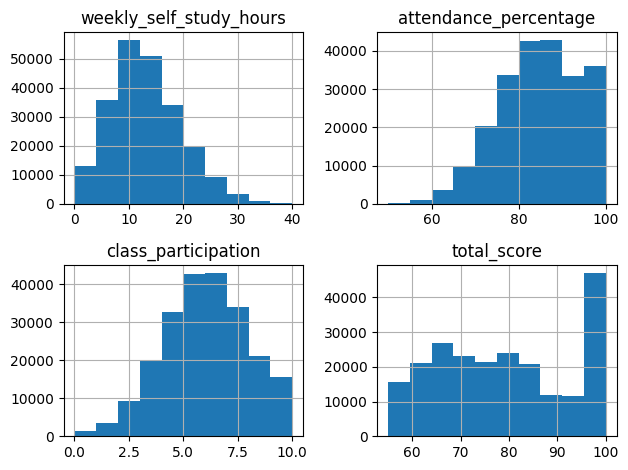

In [46]:
plt.figure(figsize=(10,8))
df[['weekly_self_study_hours',
    'attendance_percentage',
    'class_participation',
    'total_score']].hist()

plt.tight_layout()
plt.show()

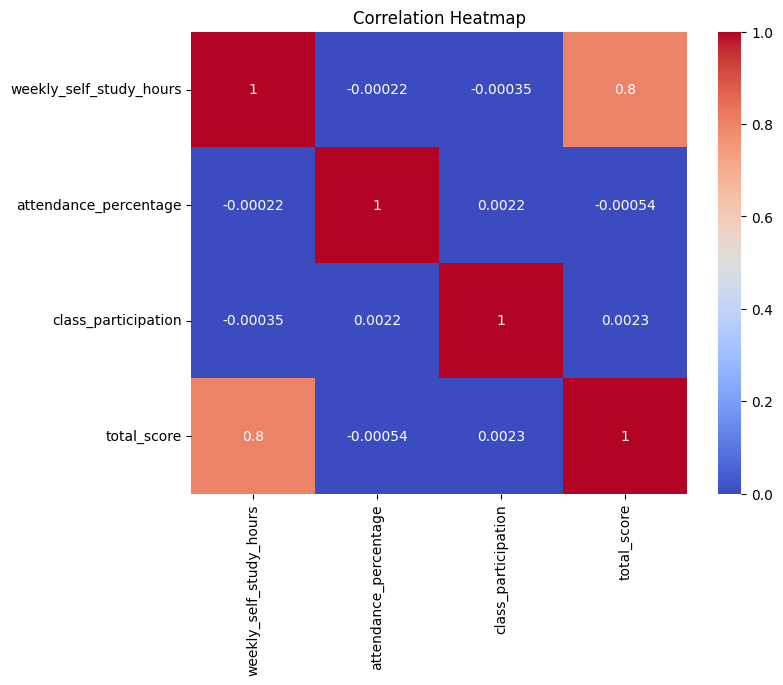

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['weekly_self_study_hours',
        'attendance_percentage',
        'class_participation',
        'total_score']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [48]:
from sklearn.metrics import classification_report

report_gb = classification_report(y_test, y_pred_gb, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

comparison = pd.DataFrame({
    'Model' : ['Gradient Boosting','Random Forest','XGBoost'],
    'Precision' : [
        report_gb['weighted avg']['precision'],
        report_rf['weighted avg']['precision'],
        report_xgb['weighted avg']['precision']
    ],
    'Recall' : [
        report_gb['weighted avg']['recall'],
        report_rf['weighted avg']['recall'],
        report_xgb['weighted avg']['recall']
    ],
    'F1-Score' : [
        report_gb['weighted avg']['f1-score'],
        report_rf['weighted avg']['f1-score'],
        report_xgb['weighted avg']['f1-score']
    ]
})

comparison

,Model,Precision,Recall,F1-Score
0,Gradient Boosting,0.998681,0.998680,0.998680
1,Random Forest,0.998726,0.998725,0.998725
2,XGBoost,0.996806,0.996801,0.996801
